In [91]:
from pathlib import Path
import sys
 
project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent
 
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
 
 
import sklearn as sk
import numpy as np
import polars as pl
import cvxopt
from src.ml.features import get_labeled_features
from cvxopt import matrix

In [92]:
Xdata = get_labeled_features('../../../data/processed/labeling_sample.csv')
Xdata.describe()

statistic,user_id,screen_name,name,followers_count,friends_count,listed_count,favourites_count,statuses_count,verified,default_profile,default_profile_image,created_at,last_tweet_at,first_seen_at,last_seen_at,profile_url,description,tweet_count,urls_per_tweet,hashtags_per_tweet,mentions_per_tweet,retweet_rate,reply_rate,unique_sources,bot_source_ratio,followers_friends_ratio,reputation,favourites_per_status,listed_per_follower,account_age_days,days_since_last_tweet,observation_span_days,tweet_frequency,tweets_per_day_in_dataset,description_length,has_description,has_url,has_location,screen_name_length,screen_name_has_digits,label
str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",420.0,"""420""","""420""",420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,"""420""","""420""","""420""","""420""","""122""","""355""",420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,419.0,420.0,420.0,419.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0,420.0
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""298""","""65""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.6313e17,null,null,5196.045238,1026.330952,34.640476,8805.935714,19065.221429,0.021429,0.588095,0.0,"""2013-10-22 20:07:02.754761""","""2018-06-16 05:53:13.933333""","""2018-06-15 15:21:48.807143""","""2018-06-16 05:53:13.933333""",null,null,2.997619,0.529609,1.605359,0.647562,0.450282,0.018262,1.071429,0.002381,44.79448,0.4501,1.387787,0.023633,1697.721429,0.616667,0.435714,0.071296,2.303571,69.619048,0.845238,0.290476,0.702381,11.002381,0.380952,0.171429
"""std""",4.1059e17,null,null,57782.513882,2727.6186,219.023297,18944.554625,41177.432631,null,null,null,null,null,null,null,null,null,4.967916,0.432737,1.435883,0.681988,0.444656,0.118165,0.292537,0.048795,625.400382,0.23705,4.022344,0.075789,1099.531765,0.798691,0.847943,0.701183,3.30621,54.172337,0.362109,0.454524,0.457756,2.694907,0.4862,0.377333
"""min""",1.5356678e7,"""0xnaomix0""","""#JeSuisProjectMaven""",0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,"""2008-07-08 18:49:55""","""2018-06-14 03:25:51""","""2018-06-14 02:38:24""","""2018-06-14 03:25:51""","""http://DanSpace77.com""",""""" Live for nothing or Die for …",1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.007853,0.0,0.0,0.0,0.0,0.0,0.0,0.000281,0.666667,0.0,0.0,0.0,0.0,5.0,0.0,0.0
"""25%""",2.59856581e8,null,null,103.0,167.0,0.0,394.0,1349.0,null,null,null,"""2011-03-02 18:52:27""","""2018-06-15 12:32:07""","""2018-06-14 15:46:42""","""2018-06-15 12:32:07""",null,null,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.374603,0.267504,0.138869,0.0,700.0,0.0,0.0,0.000563,1.0,24.0,1.0,0.0,0.0,9.0,0.0,0.0
"""50%""",1.6617e9,null,null,390.0,381.0,2.0,2128.0,7827.0,null,null,null,"""2013-08-11 05:53:23""","""2018-06-16 12:11:01""","""2018-06-15 15:25:59""","""2018-06-16 12:11:01""",null,null,1.0,0.5,1.2,0.666667,0.416667,0.0,1.0,0.0,0.857868,0.460501,0.499061,0.005634,1776.0,0.0,0.0,0.001247,1.0,61.0,1.0,0.0,1.0,11.0,0.0,0.0
"""75%""",7.5420e17,null,null,996.0,809.0,13.0,8925.0,20377.0,null,null,null,"""2016-07-16 06:38:55""","""2018-06-17 02:18:53""","""2018-06-16 13:22:50""","""2018-06-17 02:18:53""",null,null,3.0,1.0,2.0,1.0,1.0,0.0,1.0,0.0,1.476584,0.593112,1.2,0.019685,2663.0,1.0,0.0,0.003715,2.0,119.0,1.0,1.0,1.0,13.0,1.0,0.0
"""max""",1.0082e18,"""zavier_pk""","""🛸""",1.144084e6,33103.0,4064.0,202888.0,579655.0,1.0,1.0,0.0,"""2018-06-17 01:05:39""","""2018-06-17 16:54:14""","""2018-06-17 16:54:14""","""2018-06-17 16:54:14""","""https://youtu.be/tPEUnZaIc0I""","""🦀 1% Tweets Serios, 99% Drama,…",51.0,1.0,11.0,6.2,1.0,1.0,4.0,1.0,11941.0,0.999833,63.430657,0.886792,3630.0,2.0,3.0,12.0,51.0,167.0,1.0,1.0,1.0,15.0,1.0,1.0


C:\Users\Rodri\AppData\Local\Temp\ipykernel_19208\2653173486.py:10: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(Xdata[col0].to_numpy()), np.log(Xdata[col1].to_numpy()),


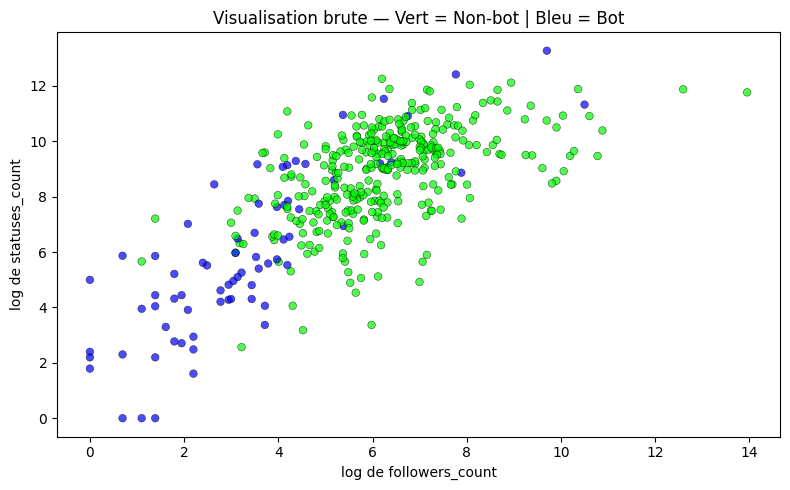

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# Deux features numériques représentatives pour une première visualisation
col0, col1 = "followers_count", "statuses_count"

point_colors = np.where(Xdata["label"].to_numpy() == 1, "#0000FF", "#00FF00")

plt.figure(figsize=(8, 5))
plt.scatter(np.log(Xdata[col0].to_numpy()), np.log(Xdata[col1].to_numpy()),
            c=point_colors, edgecolors='k', linewidths=0.4, s=30, alpha=0.7)
plt.xlabel(f'log de {col0}')
plt.ylabel(f'log de {col1}')
plt.title("Visualisation brute — Vert = Non-bot | Bleu = Bot")
plt.tight_layout()
plt.show()

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

solver = cvxopt.solvers.qp

# Colonnes à exclure : identifiants, texte libre, timestamps, label
DROP_COLS = {
    "user_id", "label",
    "screen_name", "name", "profile_url", "description",
    "created_at", "last_tweet_at", "first_seen_at", "last_seen_at",
}
feature_cols = [c for c in Xdata.columns if c not in DROP_COLS]

# Cast en Float64 dans Polars pour gérer les booléens (verified, default_profile…)
X_raw = Xdata.select([pl.col(c).cast(pl.Float64) for c in feature_cols]).to_numpy()

# Les features de tweets sont null pour les users sans tweets → on remplace par 0
X_raw = np.nan_to_num(X_raw, nan=0.0)

y = (2 * Xdata["label"] - 1).to_numpy().astype(float)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

# Split stratifié avant toute modélisation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

n, p = X_train.shape
print(f"Features utilisées : {p}")
print(f"  {feature_cols}")
print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Bots train : {(y_train==1).sum()}/{len(y_train)} | Bots test : {(y_test==1).sum()}/{len(y_test)}")

# Matrices cvxopt (hard-margin pédagogique) — sur X_train
G_np = -1.0 * np.column_stack((np.diag(y_train) @ X_train, y_train))
q_np = np.zeros(p + 1)
h_np = -1.0 * np.ones(n)
P_np = np.zeros((p + 1, p + 1))
P_np[:p, :p] = np.identity(p)

P = matrix(P_np)
q = matrix(q_np)
G = matrix(G_np)
h = matrix(h_np)

Features utilisées : 31
  ['followers_count', 'friends_count', 'listed_count', 'favourites_count', 'statuses_count', 'verified', 'default_profile', 'default_profile_image', 'tweet_count', 'urls_per_tweet', 'hashtags_per_tweet', 'mentions_per_tweet', 'retweet_rate', 'reply_rate', 'unique_sources', 'bot_source_ratio', 'followers_friends_ratio', 'reputation', 'favourites_per_status', 'listed_per_follower', 'account_age_days', 'days_since_last_tweet', 'observation_span_days', 'tweet_frequency', 'tweets_per_day_in_dataset', 'description_length', 'has_description', 'has_url', 'has_location', 'screen_name_length', 'screen_name_has_digits']
Train : (336, 31) | Test : (84, 31)
Bots train : 58/336 | Bots test : 14/84


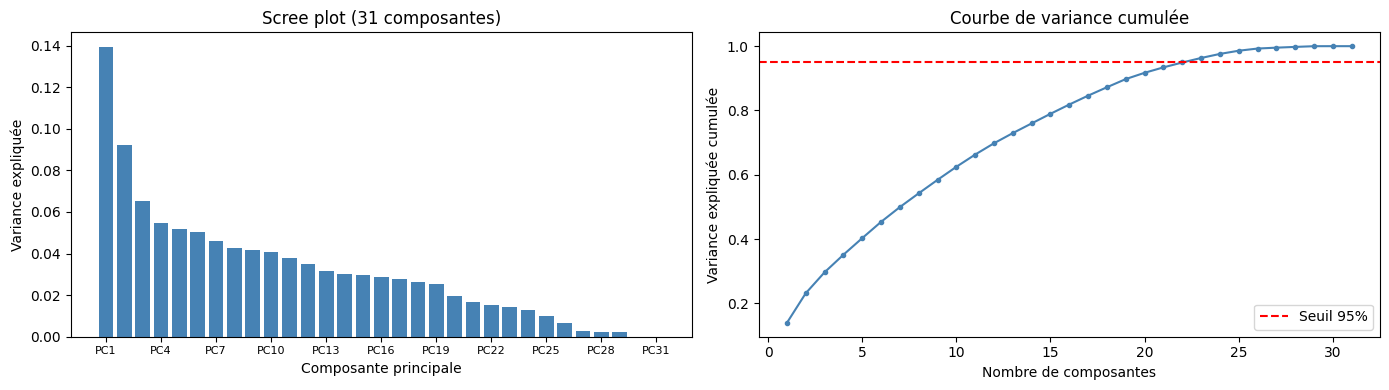

Composantes retenues : 23/31 (≥ 95% de variance)

X_train_pca : (336, 23) | X_test_pca : (84, 23)
Le SVM ci-dessous sera entraîné sur ces 23 composantes.

── Principales features par composante ACP ──
  PC1 (13.9%) : description_length (0.35), retweet_rate (0.35), has_description (0.33), account_age_days (0.32)
  PC2 (9.2%) : observation_span_days (0.48), tweet_count (0.47), days_since_last_tweet (0.33), tweets_per_day_in_dataset (0.32)
  PC3 (6.5%) : mentions_per_tweet (0.34), retweet_rate (0.31), has_url (0.29), friends_count (0.29)
  PC4 (5.5%) : bot_source_ratio (0.74), unique_sources (0.26), hashtags_per_tweet (0.23), has_url (0.19)
  PC5 (5.2%) : favourites_per_status (0.60), bot_source_ratio (0.39), screen_name_has_digits (0.38), hashtags_per_tweet (0.23)
  PC6 (5.1%) : favourites_per_status (0.49), description_length (0.31), reply_rate (0.28), unique_sources (0.28)
  PC7 (4.6%) : reply_rate (0.50), urls_per_tweet (0.40), mentions_per_tweet (0.37), account_age_days (0.35)
  PC8 

In [95]:
# 1. Matrice de covariance empirique — calculée sur X_train uniquement
V = X_train.T @ X_train / X_train.shape[0]

# 2. Diagonalisation : valeurs propres λ et vecteurs propres u
eigenvalues, eigenvectors = np.linalg.eigh(V)

# 3. Tri par ordre décroissant (eigh retourne en ordre croissant)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 4. Variance expliquée par composante
explained_ratio = eigenvalues / eigenvalues.sum()
cumvar = np.cumsum(explained_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, p + 1), explained_ratio, color='steelblue')
axes[0].set_xlabel("Composante principale")
axes[0].set_ylabel("Variance expliquée")
axes[0].set_title(f"Scree plot ({p} composantes)")
step = max(1, p // 10)
axes[0].set_xticks(range(1, p + 1, step))
axes[0].set_xticklabels([f"PC{i}" for i in range(1, p + 1, step)], fontsize=8)

axes[1].plot(range(1, p + 1), cumvar, marker='.', color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='Seuil 95%')
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance expliquée cumulée")
axes[1].set_title("Courbe de variance cumulée")
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Sélection automatique du nombre de composantes (seuil 95%)
n_components = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Composantes retenues : {n_components}/{p} (≥ 95% de variance)")
print()

# 6. Matrice de projection W : colonnes = vecteurs propres retenus
W = eigenvectors[:, :n_components]   # shape (p, n_components)

X_train_pca = X_train @ W
X_test_pca  = X_test  @ W

print(f"X_train_pca : {X_train_pca.shape} | X_test_pca : {X_test_pca.shape}")
print(f"Le SVM ci-dessous sera entraîné sur ces {n_components} composantes.\n")

# 7. Analyse des features : top contributeurs pour chaque composante retenue
feature_names = np.array(feature_cols)
print("── Principales features par composante ACP ──")
TOP_K = 4
for i in range(n_components):
    loadings = np.abs(eigenvectors[:, i])
    top_idx  = np.argsort(loadings)[::-1][:TOP_K]
    top_feats = ", ".join(
        f"{feature_names[j]} ({loadings[j]:.2f})" for j in top_idx
    )
    print(f"  PC{i+1} ({explained_ratio[i]:.1%}) : {top_feats}")

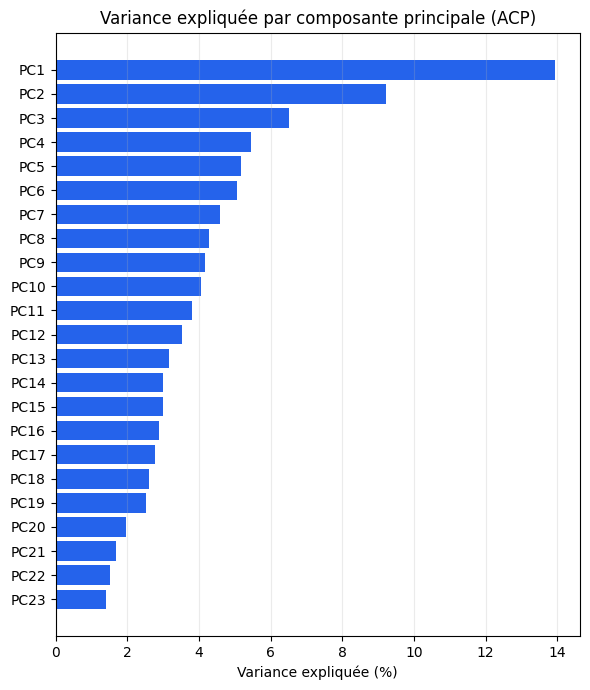

In [96]:
labels = [f"PC{i+1}" for i in range(n_components)]
values = explained_ratio[:n_components] * 100

fig, ax = plt.subplots(figsize=(6, 7))
ax.barh(labels[::-1], values[::-1], color="#2563eb")
ax.set_xlabel("Variance expliquée (%)")
ax.set_title("Variance expliquée par composante principale (ACP)")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

output_path = project_root / "docs/report/img/svm-pca-loadings.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, dpi=180, bbox_inches="tight")
plt.show()

     pcost       dcost       gap    pres   dres
 0:  2.0771e-01  2.4342e+02  2e+03  3e+00  6e+02
 1:  8.9342e-01  6.5021e+01  1e+03  2e+00  5e+02
 2:  2.2646e+00  3.1263e+02  1e+03  2e+00  3e+02
 3:  4.8241e+00  1.5192e+03  1e+03  1e+00  3e+02
 4:  1.2010e+01  3.4029e+03  1e+03  1e+00  3e+02
 5:  2.3685e+01  8.0349e+03  2e+03  1e+00  2e+02
 6:  1.3433e+01  2.2333e+04  4e+03  1e+00  2e+02
 7:  1.0904e+01  2.7319e+04  4e+03  1e+00  2e+02
 8:  1.0814e+00  8.5417e+04  9e+03  1e+00  2e+02
 9:  9.2108e-01  4.3632e+05  3e+04  1e+00  2e+02
10:  9.2669e-01  1.4018e+06  8e+04  1e+00  2e+02
11:  9.3195e-01  8.1563e+06  3e+05  1e+00  2e+02
12:  9.3414e-01  3.9174e+07  1e+06  1e+00  2e+02
13:  9.3704e-01  2.5600e+08  7e+06  1e+00  2e+02
14:  9.4431e-01  4.3554e+09  7e+07  1e+00  2e+02
15:  9.5459e-01  2.4615e+11  5e+08  1e+00  2e+02
16:  9.5778e-01  1.1283e+14  8e+09  1e+00  2e+02
Terminated (singular KKT matrix).
status : unknown
beta    : [ 0.     0.     0.     0.     0.    -0.602 -0.     0.     

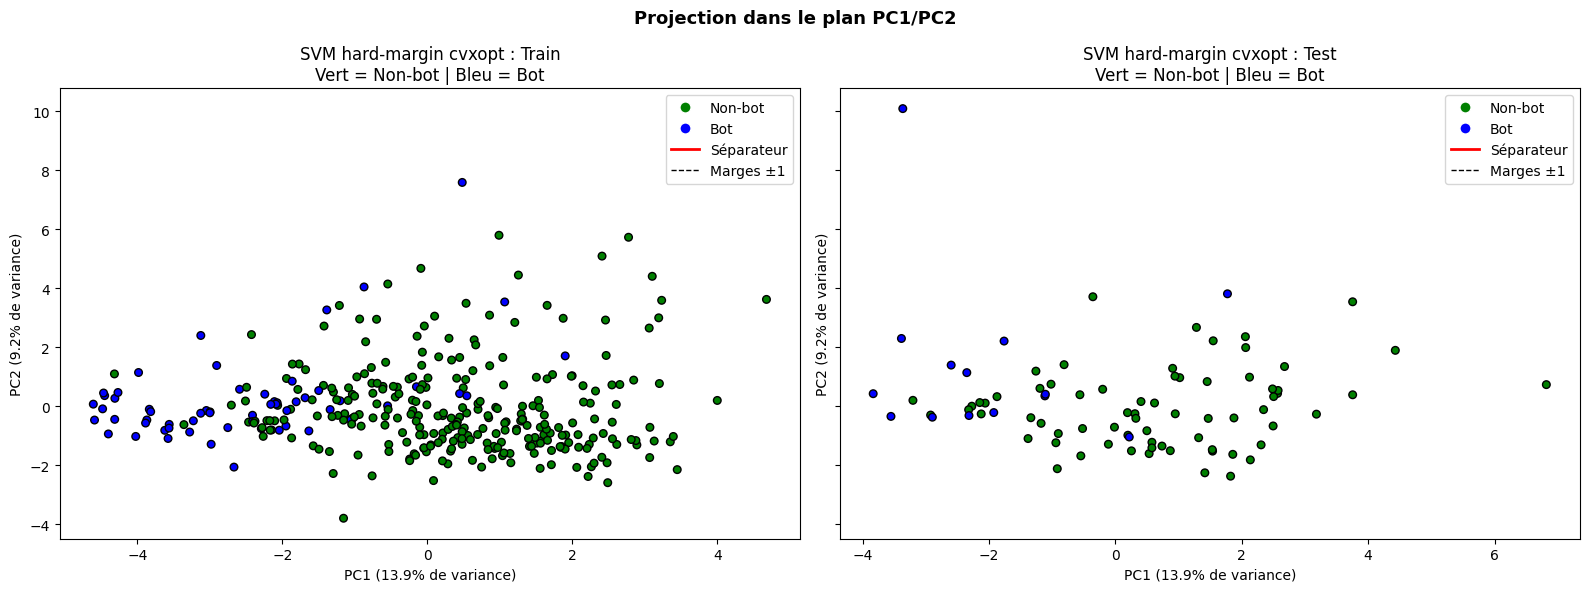

In [97]:
sol = solver(P, q, G, h)

x_sol = np.array(sol["x"]).reshape(-1)
beta  = x_sol[:p]
beta0 = x_sol[p]

print("status :", sol["status"])
print("beta    :", np.round(beta, 3))
print("beta0   :", round(beta0, 4))

# Projection de beta dans le plan PC1/PC2
W_2d    = W[:, :2]
beta_2d = W_2d.T @ beta

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

def draw_separator(ax, X_pca, y, beta_2d, beta0, title):
    colors = np.where(y == 1, "blue", "green")
    ax.scatter(X_pca[:, 0], X_pca[:, 1],
               c=colors, edgecolors='k', s=30, zorder=2)
    if sol["status"] == "optimal" and abs(beta_2d[1]) > 1e-8:
        x1_vals = np.linspace(X_pca[:, 0].min() - 0.5,
                              X_pca[:, 0].max() + 0.5, 300)
        ax.plot(x1_vals, -(beta_2d[0]*x1_vals + beta0     ) / beta_2d[1],
                color="red",   linewidth=2, label="Séparateur (f=0)")
        ax.plot(x1_vals, -(beta_2d[0]*x1_vals + beta0 - 1 ) / beta_2d[1],
                color="black", linewidth=1, linestyle="--", label="Marges (f=±1)")
        ax.plot(x1_vals, -(beta_2d[0]*x1_vals + beta0 + 1 ) / beta_2d[1],
                color="black", linewidth=1, linestyle="--")
    ax.set_xlabel(f"PC1 ({explained_ratio[0]:.1%} de variance)")
    ax.set_ylabel(f"PC2 ({explained_ratio[1]:.1%} de variance)")
    ax.set_title(title)
    ax.legend(handles=[
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Non-bot'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',  markersize=8, label='Bot'),
        plt.Line2D([0], [0], color='red',   linewidth=2, label='Séparateur'),
        plt.Line2D([0], [0], color='black', linewidth=1, linestyle='--', label='Marges ±1'),
    ])

draw_separator(axes[0], X_train_pca, y_train, beta_2d, beta0,
               "SVM hard-margin cvxopt : Train\nVert = Non-bot | Bleu = Bot")
draw_separator(axes[1], X_test_pca,  y_test,  beta_2d, beta0,
               "SVM hard-margin cvxopt : Test\nVert = Non-bot | Bleu = Bot")

plt.suptitle("Projection dans le plan PC1/PC2", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [98]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'kernel': ('rbf', 'poly', 'sigmoid'),
    'C': np.linspace(4, 15, 20),
}
svm = sk.svm.SVC(class_weight='balanced')
clf = GridSearchCV(svm, parameters, scoring='f1', cv=5, n_jobs=-1)
print(clf)

GridSearchCV(cv=5, estimator=SVC(class_weight='balanced'), n_jobs=-1,
             param_grid={'C': array([ 4.        ,  4.57894737,  5.15789474,  5.73684211,  6.31578947,
        6.89473684,  7.47368421,  8.05263158,  8.63157895,  9.21052632,
        9.78947368, 10.36842105, 10.94736842, 11.52631579, 12.10526316,
       12.68421053, 13.26315789, 13.84210526, 14.42105263, 15.        ]),
                         'kernel': ('rbf', 'poly', 'sigmoid')},
             scoring='f1')


In [99]:
clf.fit(X_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_weight='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': array([ 4. ... 15. ]), 'kernel': ('rbf', ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fol

In [100]:
y_pred = clf.predict(X_test_pca)

In [101]:
err = 1.0 - sk.metrics.accuracy_score(y_test, y_pred)
print(f"Taux d'erreur : {err:.3f}")
err

Taux d'erreur : 0.119


0.11904761904761907

In [102]:
best_svm = clf.best_estimator_

print('Meilleur modèle :', clf.best_params_)
print('Score CV        :', round(clf.best_score_, 4))
print()
print('beta0 (intercept) =', best_svm.intercept_)
print('Indices des vecteurs de support =', best_svm.support_)
print('Nombre de vecteurs de support par classe =', best_svm.n_support_)
print('|dual_coef_| max =', np.abs(best_svm.dual_coef_).max().round(4))

Meilleur modèle : {'C': np.float64(7.473684210526316), 'kernel': 'rbf'}
Score CV        : 0.727

beta0 (intercept) = [-0.08013658]
Indices des vecteurs de support = [ 16  18  27  30  39  45  46  48  50  52  59  60  67  68  71  77  78  80
  82  86  91  94  97 100 111 114 116 117 118 120 122 125 128 135 139 159
 160 177 181 188 194 200 203 208 209 212 213 220 235 240 244 246 249 250
 260 263 274 280 285 288 295 296 297 298 300 311 312 323 328 333   0  23
  32  34  35  65  66  73  92  99 113 126 127 152 170 174 176 183 184 196
 210 222 226 228 230 232 237 243 247 252 264 265 289 304 310 313 331]
Nombre de vecteurs de support par classe = [70 37]
|dual_coef_| max = 10.1051


Train : 336 samples | Test : 84 samples
Bots dans le test : 14/84 (16.7%)

── Rapport de classification ──
              precision    recall  f1-score   support

Non-bot (-1)       0.94      0.91      0.93        70
    Bot (+1)       0.62      0.71      0.67        14

    accuracy                           0.88        84
   macro avg       0.78      0.81      0.80        84
weighted avg       0.89      0.88      0.88        84



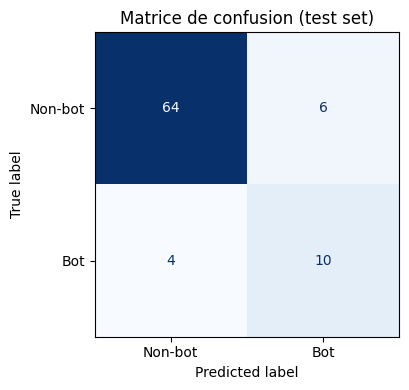

In [103]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"Train : {len(X_train_pca)} samples | Test : {len(X_test_pca)} samples")
print(f"Bots dans le test : {(y_test==1).sum()}/{len(y_test)} ({(y_test==1).mean():.1%})\n")

print("── Rapport de classification ──")
print(classification_report(y_test, y_pred, target_names=["Non-bot (-1)", "Bot (+1)"]))

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                              display_labels=["Non-bot", "Bot"])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Matrice de confusion (test set)")
plt.tight_layout()
plt.show()


In [104]:
## Courbe ROC + AUC

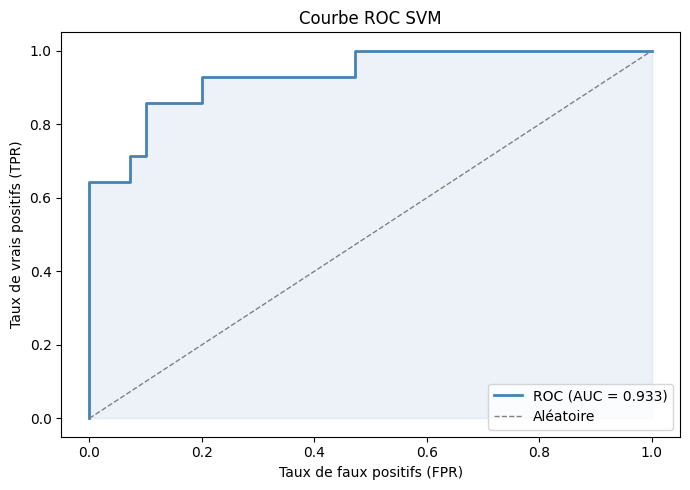

AUC : 0.9327


In [105]:
from sklearn.metrics import roc_curve, auc

y_scores = clf.decision_function(X_test_pca)
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Aléatoire')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC SVM')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC : {roc_auc:.4f}")

## Heatmap des scores GridSearch (kernel × C)

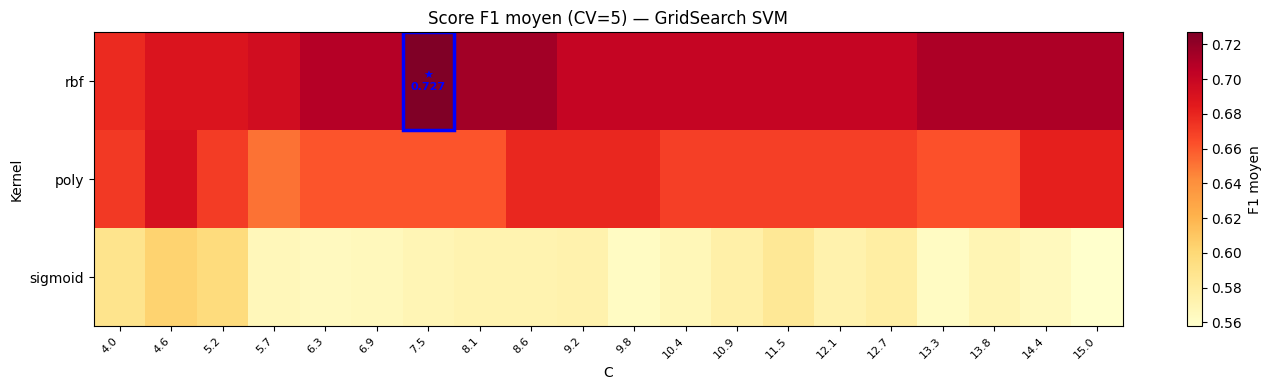

Meilleur : kernel=rbf, C=7.474, F1=0.7270


In [106]:
import pandas as pd

cv_results = pd.DataFrame(clf.cv_results_)
kernels = clf.param_grid['kernel']
C_values = clf.param_grid['C']

scores_matrix = cv_results.pivot_table(
    index='param_kernel',
    columns='param_C',
    values='mean_test_score'
).reindex(kernels)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(scores_matrix.values, aspect='auto', cmap='YlOrRd',
               vmin=scores_matrix.values.min(), vmax=scores_matrix.values.max())

ax.set_xticks(range(len(C_values)))
ax.set_xticklabels([f"{c:.1f}" for c in C_values], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(kernels)))
ax.set_yticklabels(kernels)
ax.set_xlabel('C')
ax.set_ylabel('Kernel')
ax.set_title('Score F1 moyen (CV=5) — GridSearch SVM')

plt.colorbar(im, ax=ax, label='F1 moyen')

# Annoter la meilleure cellule
best_kernel = clf.best_params_['kernel']
best_C      = clf.best_params_['C']
ki = list(kernels).index(best_kernel)
ci = list(C_values).index(best_C)
ax.add_patch(plt.Rectangle((ci - 0.5, ki - 0.5), 1, 1,
                            fill=False, edgecolor='blue', linewidth=2.5))
ax.text(ci, ki, f"★\n{clf.best_score_:.3f}", ha='center', va='center',
        fontsize=8, color='blue', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Meilleur : kernel={best_kernel}, C={best_C:.3f}, F1={clf.best_score_:.4f}")